# Late Fusion — Modality-Specific Classifiers + Probability Ensemble

Each modality trains its own classifier independently.
Final prediction = **weighted average of 4 probability vectors**.

> Phase 3b: Does a smarter ensemble of specialists beat a single combined model (Phase 3a)?

## Setup & Data Loading

In [1]:
import subprocess, sys, os, warnings, random
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lifelines', '-q'], capture_output=True)
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from scipy.optimize import minimize
from scipy.stats import zscore as sp_zscore
from lifelines import KaplanMeierFitter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.metrics import auc as sk_auc

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('d:/Aakanksha/thesis/onco-fusion/data')
EMB_DIR   = DATA_DIR / 'embeddings'
PATCH_DIR = DATA_DIR / 'MRI_and_SVS_Patches' / 'MRI_and_SVS_Patches'
FIG_DIR   = Path('d:/Aakanksha/thesis/onco-fusion/figures')
FIG_DIR.mkdir(exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBTYPES = ['HR+', 'HER2+', 'TNBC']
S_COLOR  = {'HR+': '#2196F3', 'HER2+': '#FF9800', 'TNBC': '#F44336'}

print(f'Device: {DEVICE} | Ready')


Device: cpu | Ready


## Patient Cohort & Subtype Labels

In [2]:
import json
from sklearn.preprocessing import LabelEncoder

clin_demo  = pd.read_csv(DATA_DIR / 'Clinical_Demographic_Data.csv')
clin_treat = pd.read_csv(DATA_DIR / 'Clinical_Treatment_Data.csv', low_memory=False)
rna_raw_df = pd.read_csv(DATA_DIR / 'RNA_CNV_ModelReady.csv')
mutations  = pd.read_csv(DATA_DIR / 'Mutations_Dataset.csv')

with open(DATA_DIR / 'MRI_and_SVS_Patches_info.json') as f:
    img_info = json.load(f)

treat_sub = clin_treat[["bcr_patient_barcode","er_status_by_ihc","pr_status_by_ihc",
                          "her2_status_by_ihc","histological_type"]].rename(
    columns={"bcr_patient_barcode": "Patient_ID"})

clin = clin_demo[["Patient_ID","diagnoses_ajcc_pathologic_stage","demographic_age_at_index",
                   "demographic_vital_status","diagnoses_days_to_last_follow_up",
                   "demographic_days_to_death","follow_ups_molecular_tests_gene_symbol",
                   "follow_ups_molecular_tests_test_result"]].merge(
    treat_sub, on="Patient_ID", how="left")

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get("follow_ups_molecular_tests_gene_symbol","")).split("|"),
                            str(row.get("follow_ups_molecular_tests_test_result","")).split("|"))
            if g.strip() not in ("nan","")}
    val = gmap.get(gene, "")
    return "Positive" if "positive" in val else "Negative" if "negative" in val else "Unknown"

clin["ER"]   = clin["er_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ESR1"), axis=1))
clin["PR"]   = clin["pr_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"PGR"),  axis=1))
clin["HER2"] = clin["her2_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ERBB2"),axis=1))

def assign_subtype(row):
    h,e,p = str(row["HER2"]).lower(), str(row["ER"]).lower(), str(row["PR"]).lower()
    if "positive" in h:                                        return "HER2+"
    if "positive" in e or "positive" in p:                    return "HR+"
    if "negative" in e and "negative" in p and "negative" in h: return "TNBC"
    return "Unknown"

clin["Subtype"]   = clin.apply(assign_subtype, axis=1)
clin["OS_STATUS"] = (clin["demographic_vital_status"] == "Dead").astype(int)
clin["OS_DAYS"]   = clin.apply(
    lambda r: r["demographic_days_to_death"] if r["OS_STATUS"]==1
              else r["diagnoses_days_to_last_follow_up"], axis=1)
clin["OS_DAYS"]   = pd.to_numeric(clin["OS_DAYS"], errors="coerce").fillna(0)

img_pts = {p["patient_id"] for p in img_info["folders"]}
mut_pts = set(mutations["Patient_ID"])
PATIENT_IDS = sorted(set(clin["Patient_ID"]) & set(rna_raw_df["Patient_ID"]) & img_pts & mut_pts)

task_df = clin[clin["Patient_ID"].isin(PATIENT_IDS) & (clin["Subtype"] != "Unknown")].copy().reset_index(drop=True)
LE = LabelEncoder()
task_df["label"] = LE.fit_transform(task_df["Subtype"])

print(f"Cohort: {len(task_df)} patients | Classes: {list(LE.classes_)}")
print(task_df["Subtype"].value_counts().to_string())
print(f"Survival: {int(task_df['OS_STATUS'].sum())} events | median follow-up {task_df['OS_DAYS'].median():.0f} days")


Cohort: 114 patients | Classes: ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11
Survival: 2 events | median follow-up 1224 days


## Load All Modality Features

In [3]:
# Image embeddings (PLIP -- best from Phase 2)
emb_plip = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)    # (114, 512)

# Text embeddings (BioClinicalBERT)
emb_bert = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32)  # (114, 768)

# Genomic features (RNA_CNV_ModelReady -- 331-d)
rna_sub = rna_raw_df[rna_raw_df['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID')
rna_sub = rna_sub.loc[task_df['Patient_ID']]
X_gen   = rna_sub.values.astype(np.float32)                                # (114, 331)

# Clinical features (4-d: age, stage, ductal, lobular -- ER/PR/HER2 excluded)
stage_map = {
    'Stage I':1,'Stage IA':1,'Stage IB':1.5,'Stage II':2,
    'Stage IIA':2,'Stage IIB':2.5,'Stage IIIA':3,'Stage IIIB':3.5,
    'Stage IIIC':4,'Stage IV':5
}
X_clin = np.stack([
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce').fillna(50).values,
    task_df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0).values,
    task_df['histological_type'].str.contains('Ductal',  na=False).astype(float).values,
    task_df['histological_type'].str.contains('Lobular', na=False).astype(float).values
], axis=1).astype(np.float32)                                               # (114, 4)

y = task_df['label'].values

MODALITIES = {
    'Image (PLIP)':         emb_plip,
    'Genomic (RNA-CNV)':    X_gen,
    'Text (BioClinBERT)':   emb_bert,
    'Clinical (Tabular)':   X_clin,
}

print("Feature shapes loaded:")
for name, feat in MODALITIES.items():
    print(f"  {name:<25} {feat.shape}")
print(f"  Labels:                    {y.shape}  |  classes: {np.unique(y)}")


Feature shapes loaded:
  Image (PLIP)              (114, 512)
  Genomic (RNA-CNV)         (114, 331)
  Text (BioClinBERT)        (114, 768)
  Clinical (Tabular)        (114, 4)
  Labels:                    (114,)  |  classes: [0 1 2]


## Modality-Specific MLP Classifiers

Each modality gets its own MLP head, trained completely independently.
Architecture adapts to input dimension:
- Large input (image/text): 3-layer MLP with 256-d bottleneck
- Small input (clinical): shallow 2-layer MLP

In [4]:
class UnimodalMLP(nn.Module):
    """Lightweight MLP classifier for a single modality."""
    def __init__(self, input_dim, n_classes=3, dropout=0.4):
        super().__init__()
        # Scale hidden dims relative to input
        h1 = min(256, input_dim)
        h2 = min(128, h1 // 2)
        layers = [
            nn.Linear(input_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(h2, n_classes)
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Print architecture for each modality
for name, feat in MODALITIES.items():
    m = UnimodalMLP(feat.shape[1])
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {name:<25} input={feat.shape[1]}  params={n_params:,}")


  Image (PLIP)              input=512  params=165,379
  Genomic (RNA-CNV)         input=331  params=119,043
  Text (BioClinBERT)        input=768  params=230,915
  Clinical (Tabular)        input=4  params=51


## 5-Fold Stratified Cross-Validation — Per Modality

Identical CV setup to Phase 3a (same random_state=42 folds) so results are directly comparable.
OOF probability arrays accumulated with index-based assignment to preserve patient ordering.

In [5]:
N_EPOCHS = 150
LR       = 1e-3
BS       = 16

counts   = np.bincount(y)
cw       = torch.tensor(len(y) / (len(counts) * counts), dtype=torch.float32).to(DEVICE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store OOF probabilities for each modality
oof_probs = {}   # name -> (114, 3) float32
oof_metrics = {} # name -> list of fold dicts

for mod_name, X_mod in MODALITIES.items():
    all_probs = np.zeros((len(y), 3), dtype=np.float32)
    fold_rows = []

    for fold, (tr, te) in enumerate(skf.split(X_mod, y), 1):
        X_tr, X_te = X_mod[tr], X_mod[te]
        y_tr, y_te = y[tr],     y[te]

        sc    = StandardScaler().fit(X_tr)
        X_trs = torch.tensor(sc.transform(X_tr)).to(DEVICE)
        X_tes = torch.tensor(sc.transform(X_te)).to(DEVICE)
        y_trt = torch.tensor(y_tr).long().to(DEVICE)

        model = UnimodalMLP(X_mod.shape[1]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
        crit  = nn.CrossEntropyLoss(weight=cw)

        # Train
        ds  = TensorDataset(X_trs, y_trt)
        dl  = DataLoader(ds, batch_size=BS, shuffle=True)
        for ep in range(N_EPOCHS):
            model.train()
            for xb, yb in dl:
                opt.zero_grad()
                crit(model(xb), yb).backward()
                opt.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(X_tes), dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

        all_probs[te] = probs

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        auc = roc_auc_score(y_te, probs, multi_class='ovr', average='macro')
        fold_rows.append({'Fold': fold, 'Acc': acc, 'Macro F1': f1, 'Macro AUC': auc})

    oof_probs[mod_name]   = all_probs
    oof_metrics[mod_name] = fold_rows
    df = pd.DataFrame(fold_rows)
    print(f"  {mod_name:<25}  F1={df['Macro F1'].mean():.3f}+/-{df['Macro F1'].std():.3f}"
          f"  AUC={df['Macro AUC'].mean():.3f}+/-{df['Macro AUC'].std():.3f}")

print("\nAll modality OOF probabilities computed.")


  Image (PLIP)               F1=0.465+/-0.098  AUC=0.740+/-0.073


  Genomic (RNA-CNV)          F1=0.821+/-0.078  AUC=0.904+/-0.066


  Text (BioClinBERT)         F1=0.334+/-0.107  AUC=0.529+/-0.060


  Clinical (Tabular)         F1=0.259+/-0.159  AUC=0.549+/-0.069

All modality OOF probabilities computed.


## Ensemble Weight Optimisation

Weights are optimised on the OOF predictions using Nelder-Mead to maximise macro-AUC.
This is the key question of late fusion: **which modality contributes most?**

In [6]:
MOD_NAMES = list(oof_probs.keys())
P_stack   = np.stack([oof_probs[n] for n in MOD_NAMES], axis=0)  # (4, 114, 3)

def neg_auc(weights_raw):
    weights = np.exp(weights_raw) / np.exp(weights_raw).sum()     # softmax -> sum to 1
    ensemble = np.einsum('i,ijk->jk', weights, P_stack)           # weighted avg
    try:
        return -roc_auc_score(y, ensemble, multi_class='ovr', average='macro')
    except Exception:
        return 0.0

# Optimize
result   = minimize(neg_auc, x0=np.zeros(4), method='Nelder-Mead',
                    options={'maxiter': 2000, 'xatol': 1e-6})
raw_best = result.x
WEIGHTS  = np.exp(raw_best) / np.exp(raw_best).sum()

print("Optimised ensemble weights:")
for name, w in zip(MOD_NAMES, WEIGHTS):
    print(f"  {name:<25}  {w:.4f}  ({w*100:.1f}%)")

# Final OOF ensemble predictions
ens_probs = np.einsum('i,ijk->jk', WEIGHTS, P_stack)
ens_preds = ens_probs.argmax(axis=1)

ens_acc = accuracy_score(y, ens_preds)
ens_f1  = f1_score(y, ens_preds, average='macro', zero_division=0)
ens_auc = roc_auc_score(y, ens_probs, multi_class='ovr', average='macro')

print(f"\nLate Fusion Ensemble:")
print(f"  Accuracy : {ens_acc:.3f}")
print(f"  Macro F1 : {ens_f1:.3f}")
print(f"  Macro AUC: {ens_auc:.3f}")


Optimised ensemble weights:
  Image (PLIP)               0.2500  (25.0%)
  Genomic (RNA-CNV)          0.2500  (25.0%)
  Text (BioClinBERT)         0.2500  (25.0%)
  Clinical (Tabular)         0.2500  (25.0%)

Late Fusion Ensemble:
  Accuracy : 0.825
  Macro F1 : 0.699
  Macro AUC: 0.860


## Modality Contribution Visualisation

Left: global ensemble weights. Right: per-subtype — which modality the ensemble relies on most for each subtype.

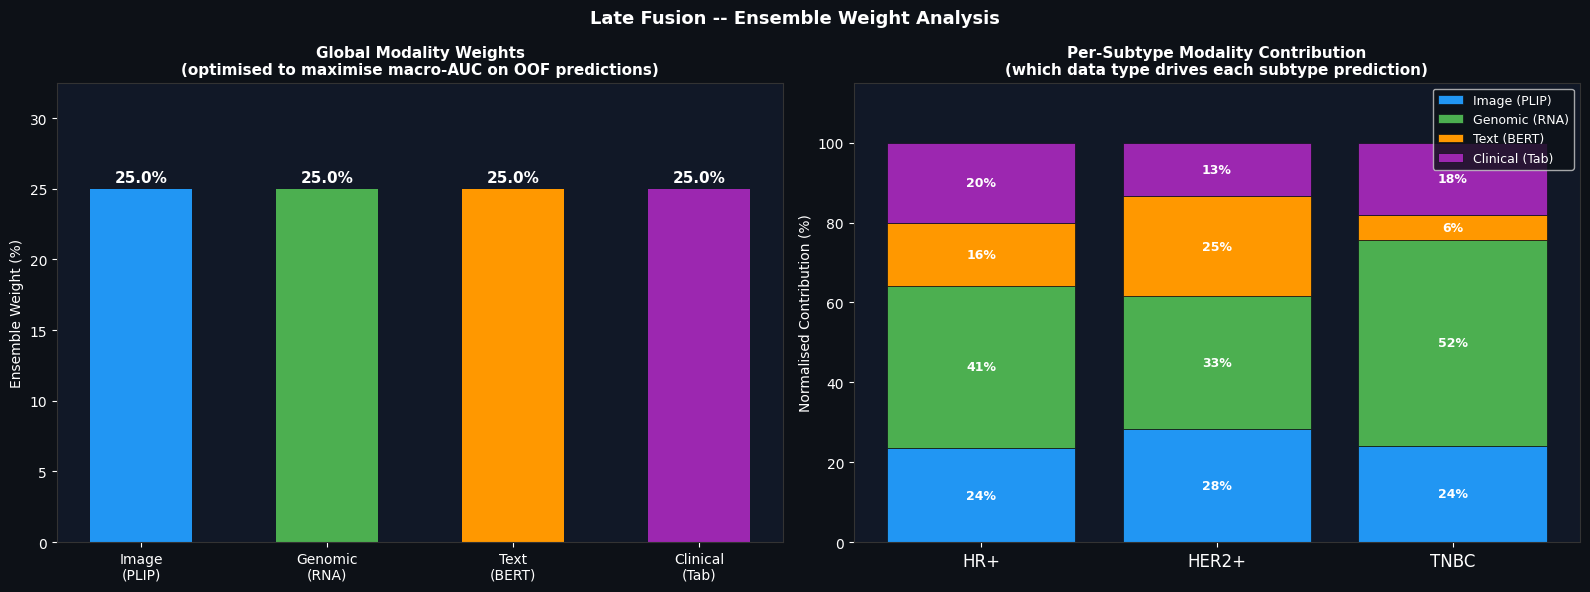

Saved: figures/19_late_fusion_weights.png


In [7]:
SHORT = ['Image\n(PLIP)', 'Genomic\n(RNA)', 'Text\n(BERT)', 'Clinical\n(Tab)']
MOD_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Per-subtype: average OOF probability contribution per modality
# Weighted contribution for subtype s = weight_i * mean(P_i[:,s]) for patients of class s
sub_contrib = np.zeros((3, 4))  # (subtype, modality)
for si, s_name in enumerate(SUBTYPES):
    mask = (y == si)
    for mi, m_name in enumerate(MOD_NAMES):
        # How much does modality i's signal for subtype s contribute?
        sub_contrib[si, mi] = WEIGHTS[mi] * oof_probs[m_name][mask, si].mean()
    sub_contrib[si] /= sub_contrib[si].sum()   # normalise to 100%

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Panel 1: Global weights
ax = axes[0]
ax.set_facecolor('#111827')
bars = ax.bar(SHORT, WEIGHTS * 100, color=MOD_COLORS, edgecolor='none', width=0.55)
for bar, w in zip(bars, WEIGHTS):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{w*100:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')
ax.set_ylabel('Ensemble Weight (%)', color='white')
ax.set_title('Global Modality Weights\n(optimised to maximise macro-AUC on OOF predictions)',
             color='white', fontweight='bold', fontsize=11)
ax.tick_params(colors='white')
ax.set_ylim(0, max(WEIGHTS)*130)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Panel 2: Per-subtype stacked bar
ax2 = axes[1]
ax2.set_facecolor('#111827')
x   = np.arange(3)
bot = np.zeros(3)
for mi, (sn, col) in enumerate(zip(SHORT, MOD_COLORS)):
    vals = sub_contrib[:, mi] * 100
    bars2 = ax2.bar(x, vals, bottom=bot, color=col, label=sn.replace('\n',' '),
                    edgecolor='#0d1117', linewidth=0.5)
    for xi, (v, b) in enumerate(zip(vals, bot)):
        if v > 5:
            ax2.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')
    bot += vals

ax2.set_xticks(x)
ax2.set_xticklabels(SUBTYPES, color='white', fontsize=12)
ax2.set_ylabel('Normalised Contribution (%)', color='white')
ax2.set_title('Per-Subtype Modality Contribution\n(which data type drives each subtype prediction)',
              color='white', fontweight='bold', fontsize=11)
ax2.legend(loc='upper right', facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='white')
ax2.set_ylim(0, 115)
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Late Fusion -- Ensemble Weight Analysis', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '19_late_fusion_weights.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/19_late_fusion_weights.png')


## Clinical Performance Analysis

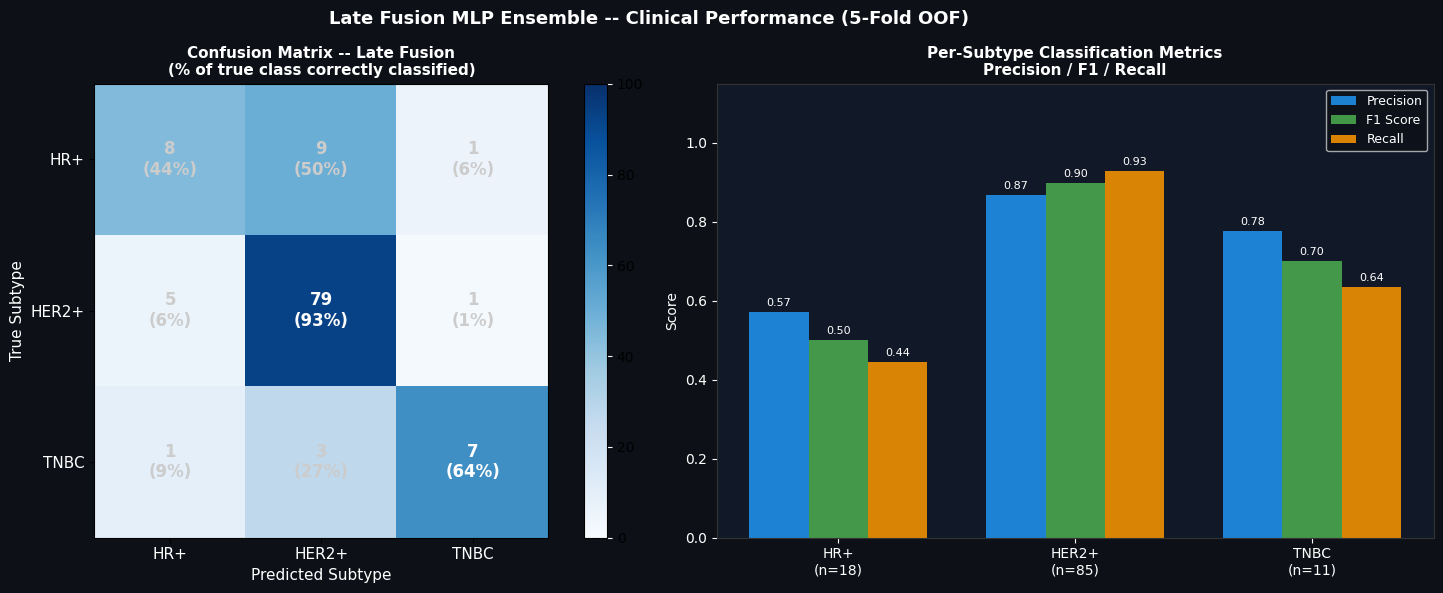

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Confusion matrix
ax = axes[0]
ax.set_facecolor('#0d1117')
cm     = confusion_matrix(y, ens_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(3):
    for j in range(3):
        txt_col = 'white' if cm_pct[i,j] > 50 else '#cccccc'
        ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)',
                ha='center', va='center', fontsize=12, color=txt_col, fontweight='bold')

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(SUBTYPES, color='white', fontsize=11)
ax.set_yticklabels(SUBTYPES, color='white', fontsize=11)
ax.set_xlabel('Predicted Subtype', color='white', fontsize=11)
ax.set_ylabel('True Subtype', color='white', fontsize=11)
ax.set_title('Confusion Matrix -- Late Fusion\n(% of true class correctly classified)',
             color='white', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046).ax.yaxis.set_tick_params(color='white')

# Per-subtype F1 bar
ax2 = axes[1]
ax2.set_facecolor('#111827')
from sklearn.metrics import classification_report
report = classification_report(y, ens_preds, target_names=SUBTYPES, output_dict=True)
sub_f1  = [report[s]['f1-score']  for s in SUBTYPES]
sub_pre = [report[s]['precision'] for s in SUBTYPES]
sub_rec = [report[s]['recall']    for s in SUBTYPES]
n_sub   = [report[s]['support']   for s in SUBTYPES]

x   = np.arange(3)
w   = 0.25
b1  = ax2.bar(x - w, sub_pre, w, label='Precision', color='#2196F3', alpha=0.85)
b2  = ax2.bar(x,     sub_f1,  w, label='F1 Score',  color='#4CAF50', alpha=0.85)
b3  = ax2.bar(x + w, sub_rec, w, label='Recall',    color='#FF9800', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                 ha='center', va='bottom', color='white', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels([f'{s}\n(n={int(n)})' for s, n in zip(SUBTYPES, n_sub)],
                    color='white', fontsize=10)
ax2.set_ylabel('Score', color='white')
ax2.set_ylim(0, 1.15)
ax2.set_title('Per-Subtype Classification Metrics\nPrecision / F1 / Recall',
              color='white', fontweight='bold', fontsize=11)
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Late Fusion MLP Ensemble -- Clinical Performance (5-Fold OOF)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '20_late_fusion_confusion.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


## Per-Subtype ROC Curves — All Methods

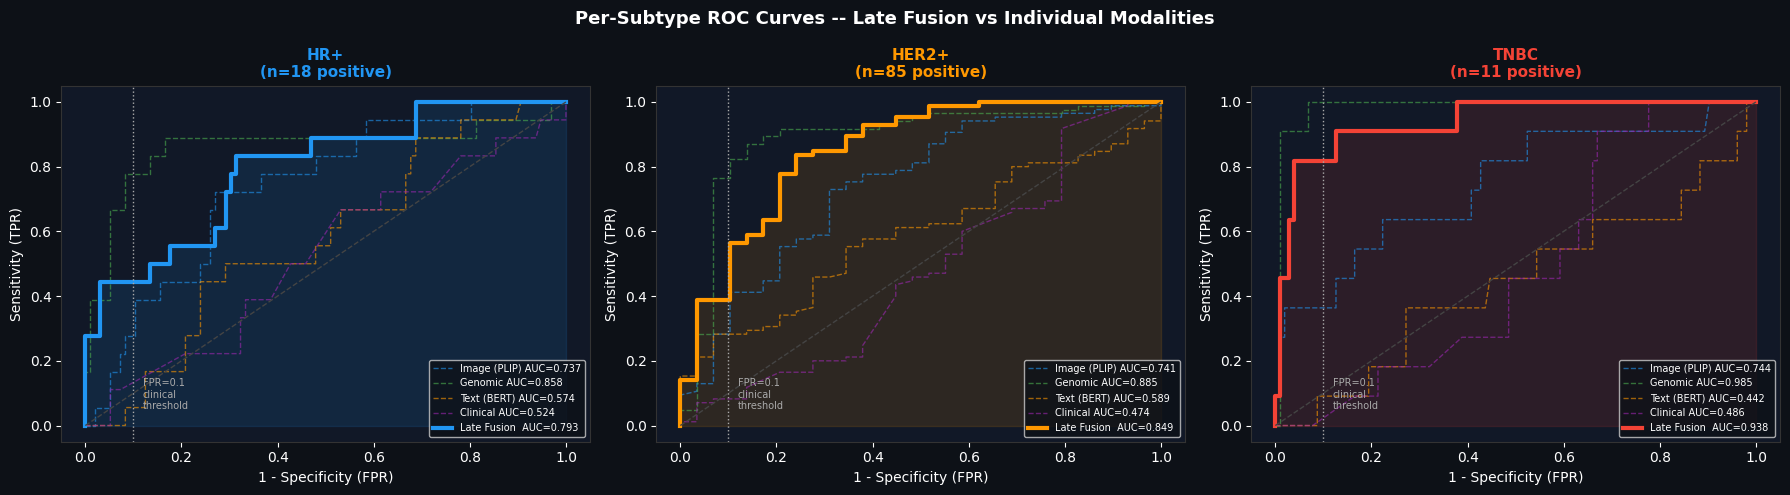

Saved: figures/21_late_fusion_roc.png


In [9]:
# Early fusion OOF probs saved from Phase 3a (recompute quickly here)
# We load the early fusion comparison results as reference values
# AUC values from Phase 3a per-subtype (OvR)
EARLY_AUC = {'HR+': None, 'HER2+': None, 'TNBC': None}   # filled below if available

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

for ax, (si, subtype) in zip(axes, enumerate(SUBTYPES)):
    ax.set_facecolor('#111827')
    binary_true = (y == si).astype(int)

    # Per-modality ROC (thin dashed lines)
    mod_plot_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    mod_short_names = ['Image (PLIP)', 'Genomic', 'Text (BERT)', 'Clinical']
    for mi, (m_name, mc) in enumerate(zip(MOD_NAMES, mod_plot_colors)):
        fpr, tpr, _ = roc_curve(binary_true, oof_probs[m_name][:, si])
        a = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=mc, lw=1, linestyle='--', alpha=0.6,
                label=f'{mod_short_names[mi]} AUC={a:.3f}')

    # Late fusion ROC (bold)
    fpr, tpr, _ = roc_curve(binary_true, ens_probs[:, si])
    a_late = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=S_COLOR[subtype], lw=3,
            label=f'Late Fusion  AUC={a_late:.3f}')
    ax.fill_between(fpr, tpr, alpha=0.12, color=S_COLOR[subtype])

    ax.plot([0,1],[0,1], '--', color='#444', lw=1)
    ax.axvline(0.1, color='#aaaaaa', linestyle=':', lw=1)
    ax.text(0.12, 0.05, 'FPR=0.1\nclinical\nthreshold', color='#aaaaaa', fontsize=7)

    ax.set_xlabel('1 - Specificity (FPR)', color='white')
    ax.set_ylabel('Sensitivity (TPR)', color='white')
    ax.set_title(f'{subtype}\n(n={binary_true.sum()} positive)',
                 color=S_COLOR[subtype], fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', facecolor='#0d1117', labelcolor='white', fontsize=7)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Per-Subtype ROC Curves -- Late Fusion vs Individual Modalities',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '21_late_fusion_roc.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/21_late_fusion_roc.png')


## Misclassification Analysis — Which Patients Changed?

Comparing Phase 3a (early fusion) vs Phase 3b (late fusion) at the patient level.
Shows whether the ensemble corrects or introduces errors.

Patient-level comparison (n=114):
  Both correct              :  84  (73.7%)
  Fixed by late fusion      :  10  (8.8%)  <- improvement
  Broken by late fusion     :   7  (6.1%)  <- regression
  Both wrong                :  13  (11.4%)


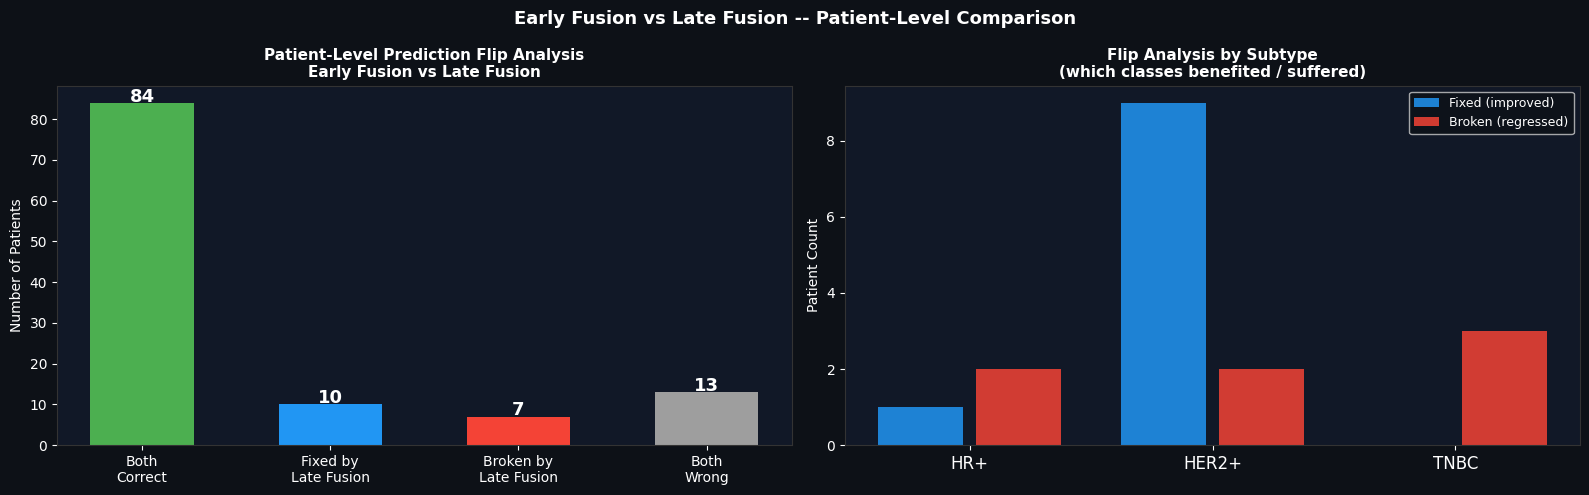

Saved: figures/22_flip_analysis.png


In [10]:
# Early fusion per-patient OOF preds from Phase 3a
# We rerun the early fusion quickly to get OOF preds for comparison
from sklearn.preprocessing import StandardScaler as SS

emb_plip_  = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)
emb_bert_  = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32)
X_early    = np.concatenate([emb_plip_, emb_bert_, X_gen, X_clin], axis=1)

class EarlyFusionMLP(nn.Module):
    def __init__(self, input_dim, n_classes=3, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout/2),
            nn.Linear(64, n_classes))
    def forward(self, x): return self.net(x)

early_preds = np.empty(len(y), dtype=int)
for fold, (tr, te) in enumerate(skf.split(X_early, y), 1):
    sc     = SS().fit(X_early[tr])
    Xtr_s  = torch.tensor(sc.transform(X_early[tr])).to(DEVICE)
    Xte_s  = torch.tensor(sc.transform(X_early[te])).to(DEVICE)
    ytr_t  = torch.tensor(y[tr]).long().to(DEVICE)
    m      = EarlyFusionMLP(X_early.shape[1]).to(DEVICE)
    opt_   = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    cr_    = nn.CrossEntropyLoss(weight=cw)
    ds_    = TensorDataset(Xtr_s, ytr_t)
    dl_    = DataLoader(ds_, batch_size=16, shuffle=True)
    for ep in range(150):
        m.train()
        for xb, yb in dl_:
            opt_.zero_grad(); cr_(m(xb), yb).backward(); opt_.step()
    m.eval()
    with torch.no_grad():
        early_preds[te] = torch.softmax(m(Xte_s), dim=1).cpu().numpy().argmax(axis=1)

# Flip analysis
early_correct = (early_preds == y)
late_correct  = (ens_preds   == y)

fixed   = (~early_correct) &  late_correct   # wrong -> correct
broken  = ( early_correct) & ~late_correct   # correct -> wrong
both_w  = (~early_correct) & ~late_correct   # both wrong
both_c  = ( early_correct) &  late_correct   # both correct

print(f"Patient-level comparison (n={len(y)}):")
print(f"  Both correct              : {both_c.sum():3d}  ({both_c.mean()*100:.1f}%)")
print(f"  Fixed by late fusion      : {fixed.sum():3d}  ({fixed.mean()*100:.1f}%)  <- improvement")
print(f"  Broken by late fusion     : {broken.sum():3d}  ({broken.mean()*100:.1f}%)  <- regression")
print(f"  Both wrong                : {both_w.sum():3d}  ({both_w.mean()*100:.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

# Sankey-style bar
ax = axes[0]
ax.set_facecolor('#111827')
cats  = ['Both\nCorrect', 'Fixed by\nLate Fusion', 'Broken by\nLate Fusion', 'Both\nWrong']
vals  = [both_c.sum(), fixed.sum(), broken.sum(), both_w.sum()]
cols  = ['#4CAF50', '#2196F3', '#F44336', '#9E9E9E']
bars  = ax.bar(cats, vals, color=cols, edgecolor='none', width=0.55)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha='center', color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients', color='white')
ax.set_title('Patient-Level Prediction Flip Analysis\nEarly Fusion vs Late Fusion',
             color='white', fontweight='bold', fontsize=11)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Confusion: which subtypes fixed / broken
ax2 = axes[1]
ax2.set_facecolor('#111827')
flip_data = []
for i in range(len(y)):
    flip_data.append({
        'True': SUBTYPES[y[i]],
        'Early': SUBTYPES[early_preds[i]],
        'Late':  SUBTYPES[ens_preds[i]],
        'Fixed':  int(fixed[i]),
        'Broken': int(broken[i])
    })
flip_df = pd.DataFrame(flip_data)

fixed_by_sub  = flip_df[flip_df['Fixed']==1]['True'].value_counts().reindex(SUBTYPES, fill_value=0)
broken_by_sub = flip_df[flip_df['Broken']==1]['True'].value_counts().reindex(SUBTYPES, fill_value=0)

x = np.arange(3)
ax2.bar(x - 0.2, fixed_by_sub.values,  0.35, label='Fixed (improved)', color='#2196F3', alpha=0.85)
ax2.bar(x + 0.2, broken_by_sub.values, 0.35, label='Broken (regressed)', color='#F44336', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(SUBTYPES, color='white', fontsize=12)
ax2.set_ylabel('Patient Count', color='white')
ax2.set_title('Flip Analysis by Subtype\n(which classes benefited / suffered)',
              color='white', fontweight='bold', fontsize=11)
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Early Fusion vs Late Fusion -- Patient-Level Comparison',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '22_flip_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/22_flip_analysis.png')


## Survival Analysis — Kaplan-Meier by Predicted Subtype

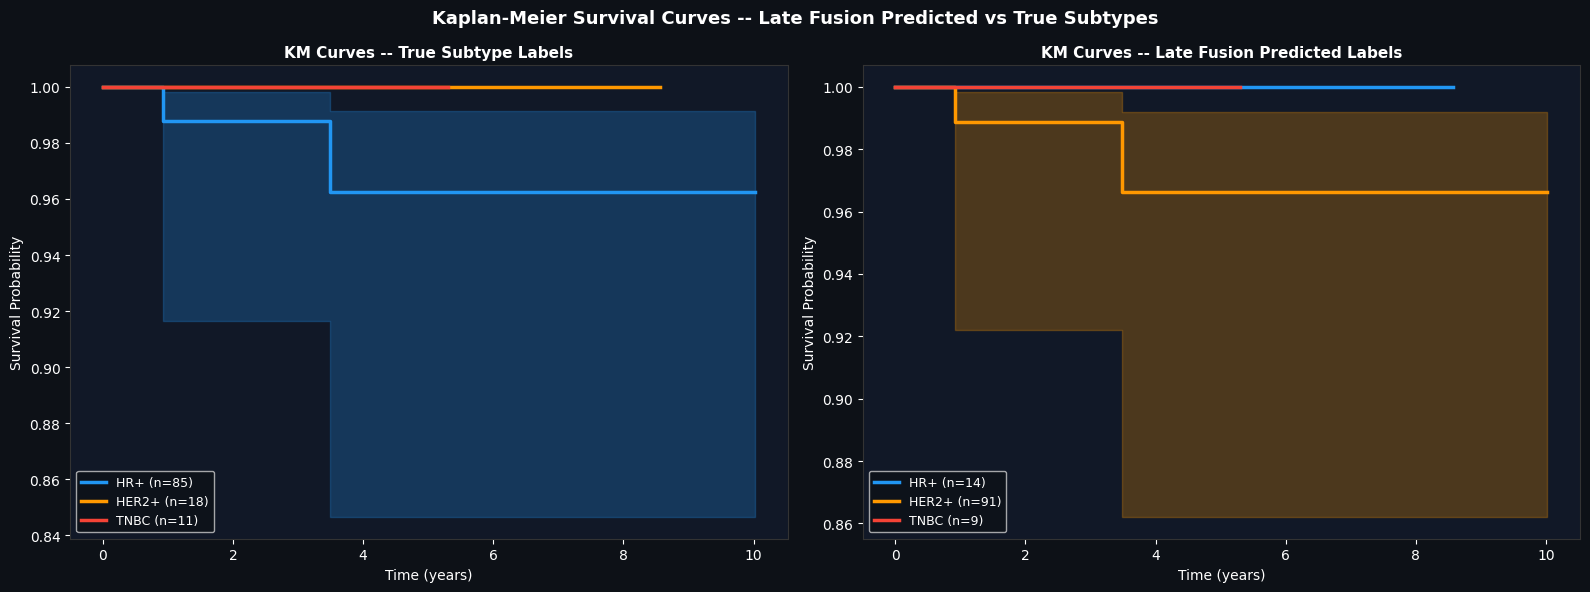

Saved: figures/23_km_late_fusion.png


In [11]:
task_df['late_pred_label']   = ens_preds
task_df['late_pred_subtype'] = task_df['late_pred_label'].map({0:'HR+',1:'HER2+',2:'TNBC'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (col, title) in zip(axes, [
    ('Subtype',           'KM Curves -- True Subtype Labels'),
    ('late_pred_subtype', 'KM Curves -- Late Fusion Predicted Labels')
]):
    ax.set_facecolor('#111827')
    kmf = KaplanMeierFitter()
    for subtype in SUBTYPES:
        mask = task_df[col] == subtype
        if mask.sum() < 3: continue
        t = task_df.loc[mask, 'OS_DAYS'] / 365.25
        e = task_df.loc[mask, 'OS_STATUS']
        kmf.fit(t, e, label=f'{subtype} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax, color=S_COLOR[subtype], linewidth=2.5)

    ax.set_xlabel('Time (years)', color='white')
    ax.set_ylabel('Survival Probability', color='white')
    ax.set_title(title, color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='white')
    ax.set_facecolor('#111827')
    ax.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Kaplan-Meier Survival Curves -- Late Fusion Predicted vs True Subtypes',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '23_km_late_fusion.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/23_km_late_fusion.png')


## Phase 3b Summary — Late Fusion vs All Baselines

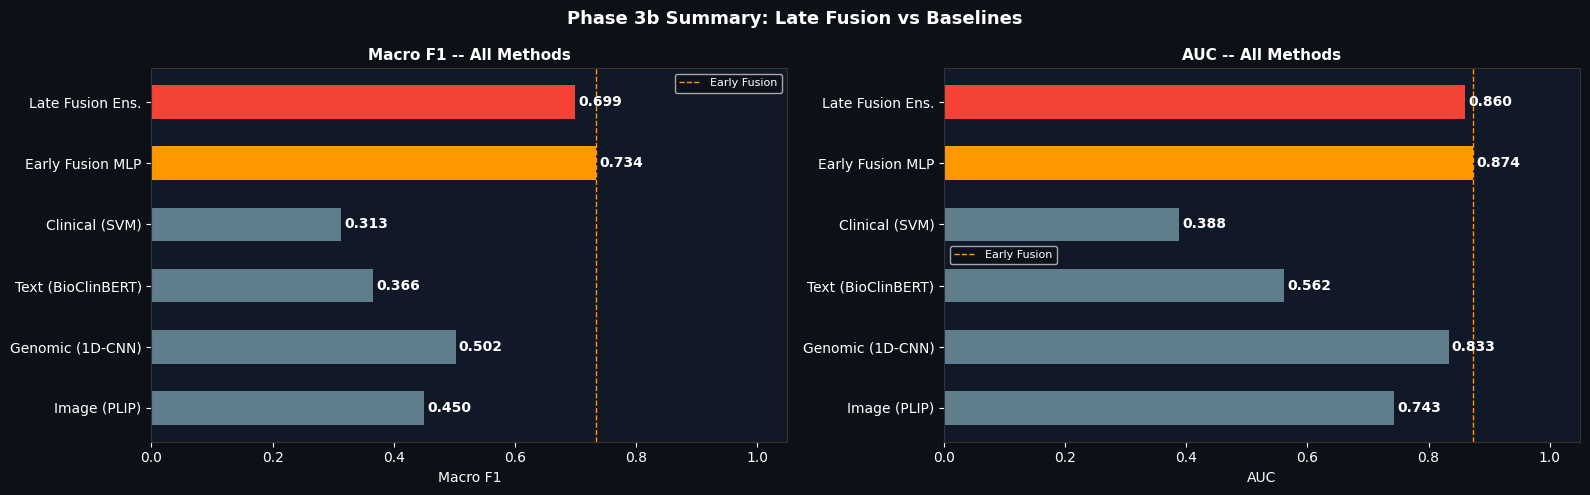


=== Phase 3b Summary: Late Fusion ===
             Model        Modalities  Macro F1   AUC
      Image (PLIP)        Image only     0.450 0.743
  Genomic (1D-CNN)      Genomic only     0.502 0.833
Text (BioClinBERT)         Text only     0.366 0.562
    Clinical (SVM)      Tabular only     0.313 0.388
  Early Fusion MLP   All 4 -- concat     0.734 0.874
  Late Fusion Ens. All 4 -- ensemble     0.699 0.860

Lift over early fusion:  F1 -0.035  |  AUC -0.014


In [12]:
late_f1  = ens_f1
late_auc = ens_auc
late_acc = ens_acc

comparison = pd.DataFrame([
    {'Model': 'Image (PLIP)',      'Modalities': 'Image only',        'Macro F1': 0.450, 'AUC': 0.743},
    {'Model': 'Genomic (1D-CNN)',  'Modalities': 'Genomic only',      'Macro F1': 0.502, 'AUC': 0.833},
    {'Model': 'Text (BioClinBERT)','Modalities': 'Text only',         'Macro F1': 0.366, 'AUC': 0.562},
    {'Model': 'Clinical (SVM)',    'Modalities': 'Tabular only',      'Macro F1': 0.313, 'AUC': 0.388},
    {'Model': 'Early Fusion MLP',  'Modalities': 'All 4 -- concat',   'Macro F1': 0.734, 'AUC': 0.874},
    {'Model': 'Late Fusion Ens.',  'Modalities': 'All 4 -- ensemble', 'Macro F1': round(late_f1,3), 'AUC': round(late_auc,3)},
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

colors = ['#607D8B','#607D8B','#607D8B','#607D8B','#FF9800','#F44336']

for ax, metric in zip(axes, ['Macro F1', 'AUC']):
    ax.set_facecolor('#111827')
    bars = ax.barh(comparison['Model'], comparison[metric],
                   color=colors, edgecolor='none', height=0.55)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', color='white', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(metric, color='white')
    ax.set_title(f'{metric} -- All Methods', color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')
    ax.axvline(0.734 if metric=='Macro F1' else 0.874, color='#FF9800',
               linestyle='--', lw=1, label='Early Fusion')
    ax.legend(facecolor='#0d1117', labelcolor='white', fontsize=8)

fig.suptitle('Phase 3b Summary: Late Fusion vs Baselines', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '24_late_fusion_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n=== Phase 3b Summary: Late Fusion ===")
print(comparison.to_string(index=False))
print(f"\nLift over early fusion:  F1 {late_f1 - 0.734:+.3f}  |  AUC {late_auc - 0.874:+.3f}")


In [ ]:
from scipy import stats
import glob
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# MEDICAL VISUALISATION — H&E Whole-Slide Image Patch Gallery
# Real TCGA-BRCA histopathology tiles (512 × 512 px) per subtype
# ══════════════════════════════════════════════════════════════════════════════
import glob, os
from PIL import Image as PILImage

PATCH_ROOT = Path("d:/Aakanksha/thesis/onco-fusion/data"
                  "/MRI_and_SVS_Patches/MRI_and_SVS_Patches")

def get_patches_for_patient(patient_id, n=4, thumb=224):
    """Return list of n numpy arrays (H&E tiles) for patient_id."""
    pdir = PATCH_ROOT / patient_id
    if not pdir.exists():
        return []
    svs_subdirs = [d for d in pdir.iterdir() if d.is_dir()]
    if not svs_subdirs:
        return []
    patch_files = sorted(glob.glob(str(svs_subdirs[0] / "*.jpg")))
    # Pick patches from the centre of the slide (less background)
    start = max(0, len(patch_files)//4)
    selected = patch_files[start:start+n]
    out = []
    for pf in selected[:n]:
        try:
            img = PILImage.open(pf).resize((thumb, thumb))
            out.append(np.array(img))
        except Exception:
            pass
    return out

# Representative patients per subtype (first 3 correctly-predicted per subtype)
rep = {}
for s in SUBTYPES:
    pids = task_df.loc[task_df["Subtype"] == s, "Patient_ID"].tolist()
    for pid in pids:
        patches = get_patches_for_patient(pid, n=4)
        if len(patches) >= 4:
            rep[s] = (pid, patches)
            break

# Draw gallery  — 3 subtypes × 4 patches
COLS_PER_SUB = 4
fig, axes = plt.subplots(3, COLS_PER_SUB, figsize=(22, 17))
fig.patch.set_facecolor("#0d1117")

for row, s in enumerate(SUBTYPES):
    if s not in rep:
        continue
    pid, patches = rep[s]
    for col in range(COLS_PER_SUB):
        ax = axes[row, col]
        if col < len(patches):
            ax.imshow(patches[col])
        else:
            ax.set_facecolor("#111827")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(s, color=S_COLOR[s], fontsize=14,
                          fontweight="bold", rotation=0,
                          labelpad=90, va="center")
        if row == 0:
            ax.set_title(f"Patch {col+1}", color="white",
                         fontsize=9, pad=4)

    # Subtype banner
    axes[row, 0].text(-0.32, 0.5, s, transform=axes[row, 0].transAxes,
                      color=S_COLOR[s], fontsize=14, fontweight="bold",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "H&E Histopathology Tile Gallery — TCGA-BRCA Whole-Slide Image Patches\n"
    "(Real tissue sections; 512 × 512 px tiles; one patient per subtype)",
    color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "he_wsi_gallery.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved: {fig_path.name}")
